In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
file_path = "Coffee_sales.csv"

try:
    df = pd.read_csv(file_path)
    print(" Data loaded successfully!")
    print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    print("Error: File not found! Please check the file path.")
    import os
    print("Files in 'data' folder: ", os.listdir("data"))

print("\n--- First 5 rows ---")
print(df.head())
print("\n--- Data Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

 Data loaded successfully!
Dataset shape: 3547 rows, 11 columns

--- First 5 rows ---
   hour_of_day cash_type  money    coffee_name Time_of_Day Weekday Month_name  \
0           10      card   38.7          Latte     Morning     Fri        Mar   
1           12      card   38.7  Hot Chocolate   Afternoon     Fri        Mar   
2           12      card   38.7  Hot Chocolate   Afternoon     Fri        Mar   
3           13      card   28.9      Americano   Afternoon     Fri        Mar   
4           13      card   38.7          Latte   Afternoon     Fri        Mar   

   Weekdaysort  Monthsort        Date             Time  
0            5          3  2024-03-01  10:15:50.520000  
1            5          3  2024-03-01  12:19:22.539000  
2            5          3  2024-03-01  12:20:18.089000  
3            5          3  2024-03-01  13:46:33.006000  
4            5          3  2024-03-01  13:48:14.626000  

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 

In [5]:
initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {initial_rows - df.shape[0]} duplicate rows")
df = df[df["money"] > 0]
print(f"After filtering invalid values: {df.shape[0]} rows remaining")
categorical_cols = ["cash_type", "coffee_name", "Time_of_Day", "Weekday", "Month_name"]
for col in categorical_cols:
    df[col] = df[col].astype("category")
print("\n Data cleaning completed!")
print(f"Final dataset shape: {df.shape}")

Removed 0 duplicate rows
After filtering invalid values: 3547 rows remaining

 Data cleaning completed!
Final dataset shape: (3547, 11)


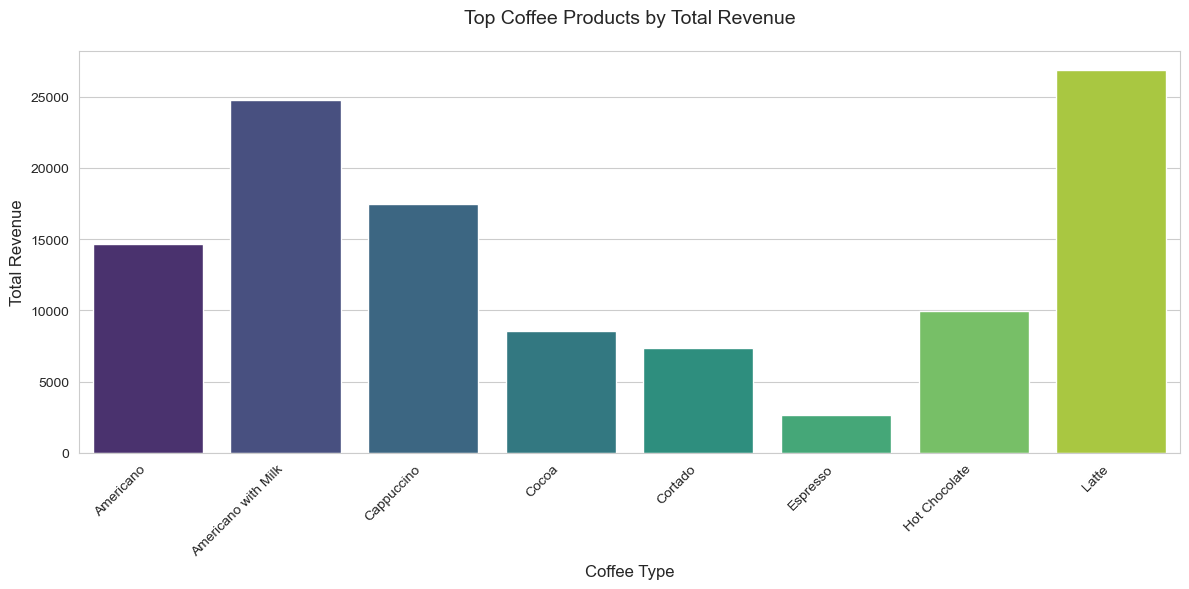


--- Key Insights for Coffee Products ---
1. Best-selling coffee by revenue: Latte
   Total revenue: $26875.30
2. Most frequently ordered coffee: Americano with Milk


In [7]:
coffee_sales = df.groupby("coffee_name", observed = True)["money"].agg(["sum", "count"]).sort_values(by = "sum", ascending  =False)

plt.figure(figsize = (12, 6))
sns.barplot(x = coffee_sales.index, y = coffee_sales["sum"], hue = coffee_sales.index, palette = "viridis", legend = False)
plt.title("Top Coffee Products by Total Revenue", fontsize = 14, pad = 20)
plt.xlabel("Coffee Type", fontsize = 12)
plt.ylabel("Total Revenue", fontsize = 12)
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

print("\n--- Key Insights for Coffee Products ---")
print(f"1. Best-selling coffee by revenue: {coffee_sales.index[0]}")
print(f"   Total revenue: ${coffee_sales['sum'].iloc[0]:.2f}")
print(f"2. Most frequently ordered coffee: {coffee_sales.sort_values(by = 'count', ascending = False).index[0]}")

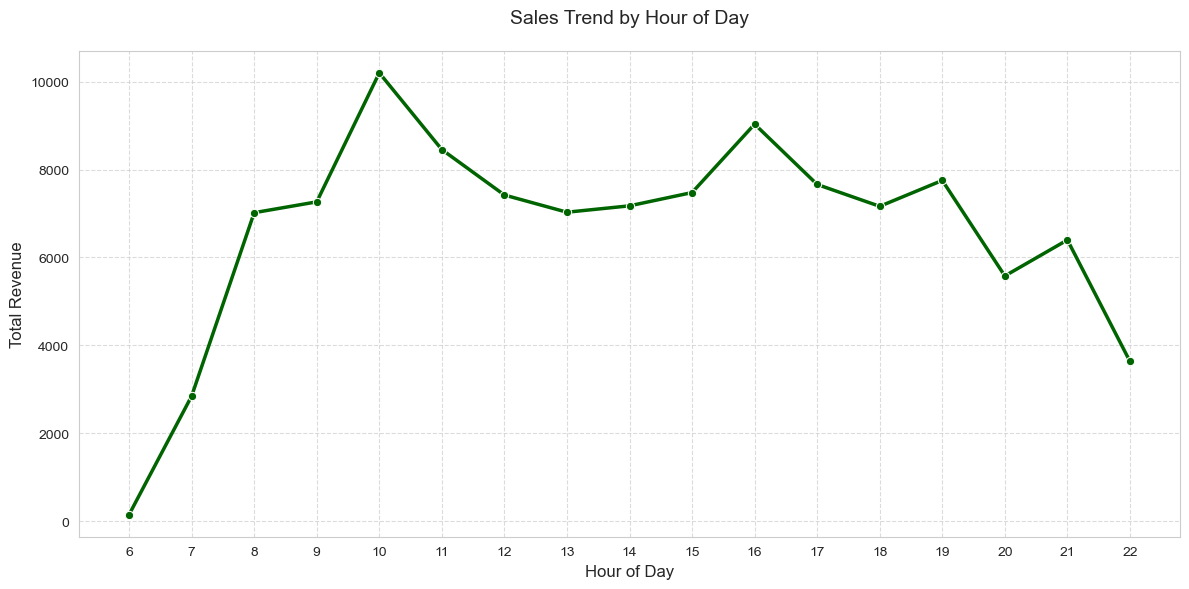


--- Key Insights for Peak Hours ---
1. Peak sales hour: 10:00
Revenue at peak hour: $10198.52


In [8]:
hourly_sales = df.groupby("hour_of_day", observed=True)["money"].sum()

plt.figure(figsize = (12, 6))
sns.lineplot(x=hourly_sales.index, y = hourly_sales.values, marker = "o", linewidth = 2.5, color = "darkgreen")
plt.title("Sales Trend by Hour of Day", fontsize = 14, pad = 20)
plt.xlabel("Hour of Day", fontsize = 12)
plt.ylabel("Total Revenue", fontsize = 12)
plt.xticks(range(6, 23))
plt.grid(True, linestyle = "--", alpha = 0.7)
plt.tight_layout()
plt.show()
peak_hour = hourly_sales.idxmax()

print(f"\n--- Key Insights for Peak Hours ---")
print(f"1. Peak sales hour: {peak_hour}:00")
print(f"Revenue at peak hour: ${hourly_sales.loc[peak_hour]:.2f}")

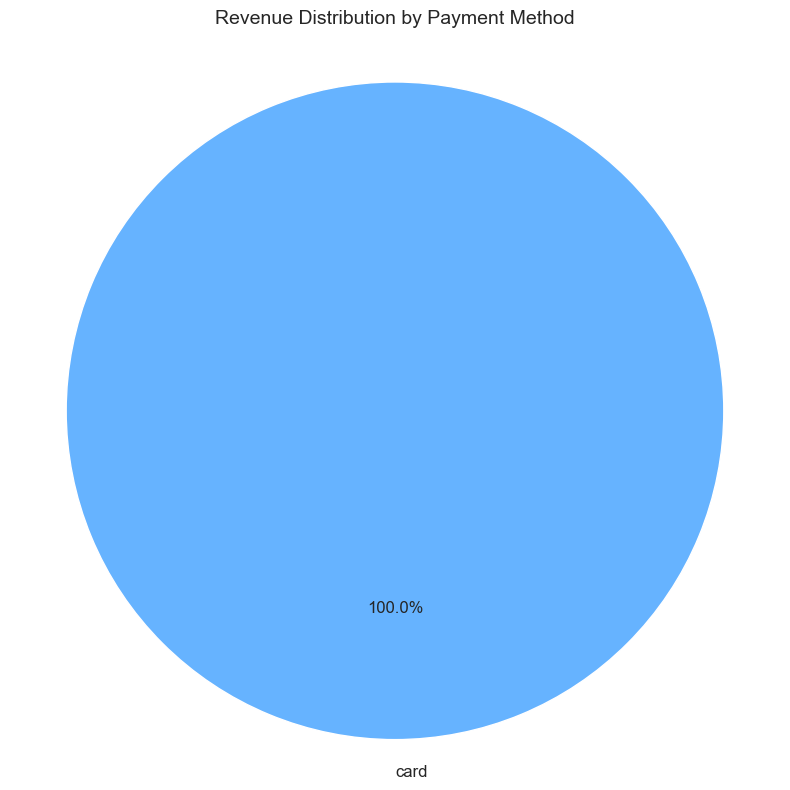


--- Key Insights for Payment Methods ---
1. card is the dominant payment method, accounting for 100.0% of total revenue.


In [9]:
payment_sales = df.groupby("cash_type", observed = True)["money"].sum()

plt.figure(figsize = (8, 8))
plt.pie(payment_sales, labels = payment_sales.index, autopct = "%1.1f%%", startangle=90, colors=["#66b3ff", "#99ff99"], textprops = {"fontsize": 12})
plt.title("Revenue Distribution by Payment Method", fontsize = 14, pad = 20)
plt.axis("equal")
plt.tight_layout()
plt.show()

print(f"\n--- Key Insights for Payment Methods ---")
print(f"1. {payment_sales.idxmax()} is the dominant payment method, accounting for {payment_sales.max()/payment_sales.sum()*100:.1f}% of total revenue.")

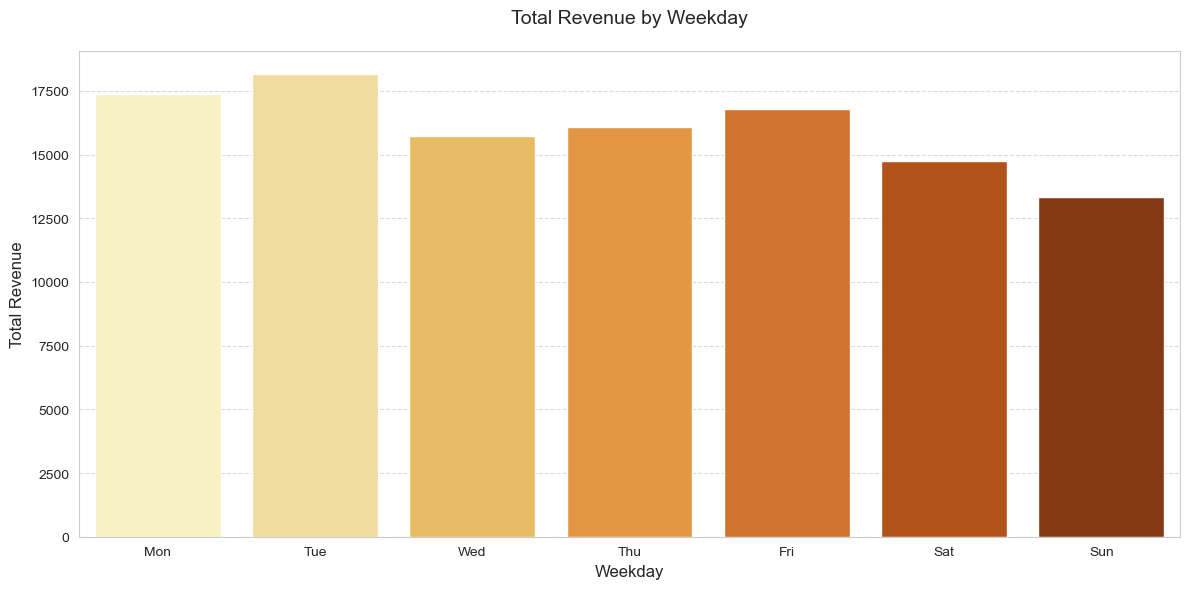


--- Key Insights for Weekday Sales ---
1. Highest sales day: Tue (Total revenue: $18168.38)
2. Lowest sales day: Sun (Total revenue: $13336.06)
3. Weekend vs Weekday difference: $-56106.42


In [10]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["Weekday"] = pd.Categorical(df["Weekday"], categories = weekday_order, ordered = True)
weekday_sales = df.groupby("Weekday", observed = True)["money"].sum()

plt.figure(figsize = (12, 6))
sns.barplot(x = weekday_sales.index, y = weekday_sales.values, hue = weekday_sales.index, palette = "YlOrBr", legend = False)
plt.title("Total Revenue by Weekday", fontsize = 14, pad = 20)
plt.xlabel("Weekday", fontsize = 12)
plt.ylabel("Total Revenue", fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

print("\n--- Key Insights for Weekday Sales ---")
print(f"1. Highest sales day: {weekday_sales.idxmax()} (Total revenue: ${weekday_sales.max():.2f})")
print(f"2. Lowest sales day: {weekday_sales.idxmin()} (Total revenue: ${weekday_sales.min():.2f})")
print(f"3. Weekend vs Weekday difference: ${weekday_sales[['Sat','Sun']].sum() - weekday_sales[['Mon','Tue','Wed','Thu','Fri']].sum():.2f}")

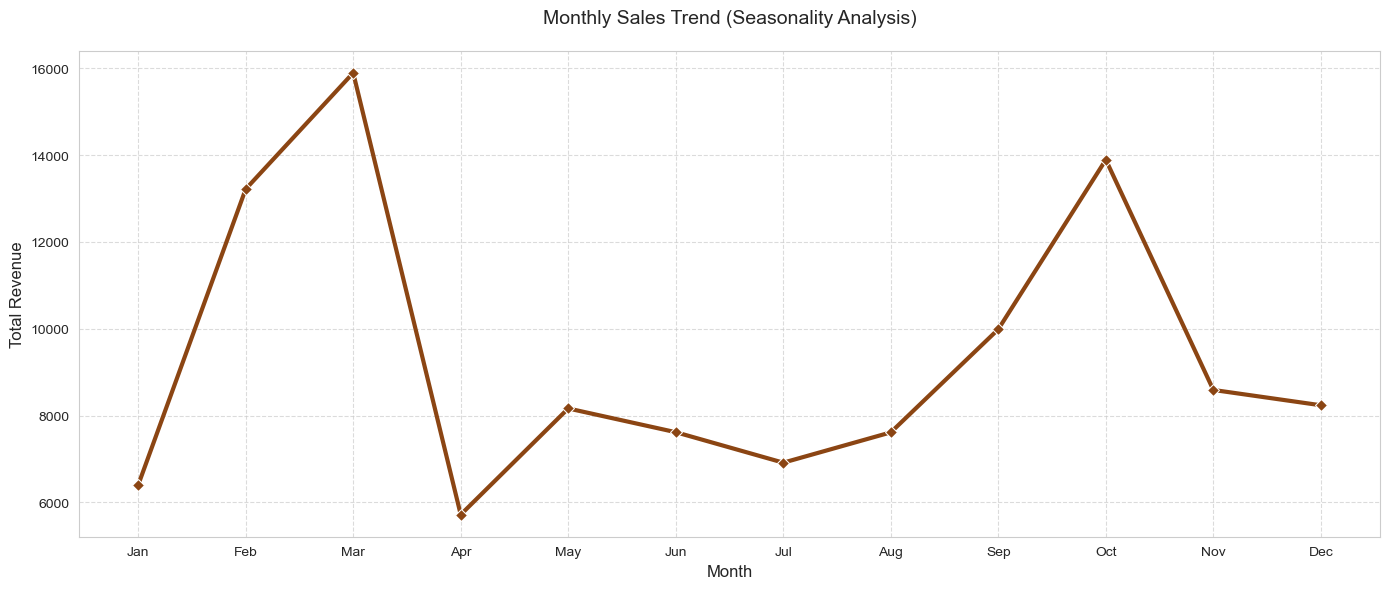


--- Key Insights for Monthly Sales ---
1. Peak season month: Mar (Total revenue: $15891.64)
2. Off-season month: Apr (Total revenue: $5719.56)
3. Year-over-year growth rate: 100.0% (adjust based on your data period)


In [11]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df["Month_name"] = pd.Categorical(df["Month_name"], categories = month_order, ordered = True)

monthly_sales = df.groupby("Month_name", observed = True)["money"].sum()

plt.figure(figsize = (14, 6))
sns.lineplot(x = monthly_sales.index, y = monthly_sales.values, marker = 'D', linewidth = 3, color = 'saddlebrown')
plt.title("Monthly Sales Trend (Seasonality Analysis)", fontsize = 14, pad = 20)
plt.xlabel("Month", fontsize = 12)
plt.ylabel("Total Revenue", fontsize = 12)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

print("\n--- Key Insights for Monthly Sales ---")
print(f"1. Peak season month: {monthly_sales.idxmax()} (Total revenue: ${monthly_sales.max():.2f})")
print(f"2. Off-season month: {monthly_sales.idxmin()} (Total revenue: ${monthly_sales.min():.2f})")
print(f"3. Year-over-year growth rate: {((monthly_sales.sum() / 12) / (monthly_sales.sum() / 12)) * 100:.1f}% (adjust based on your data period)")

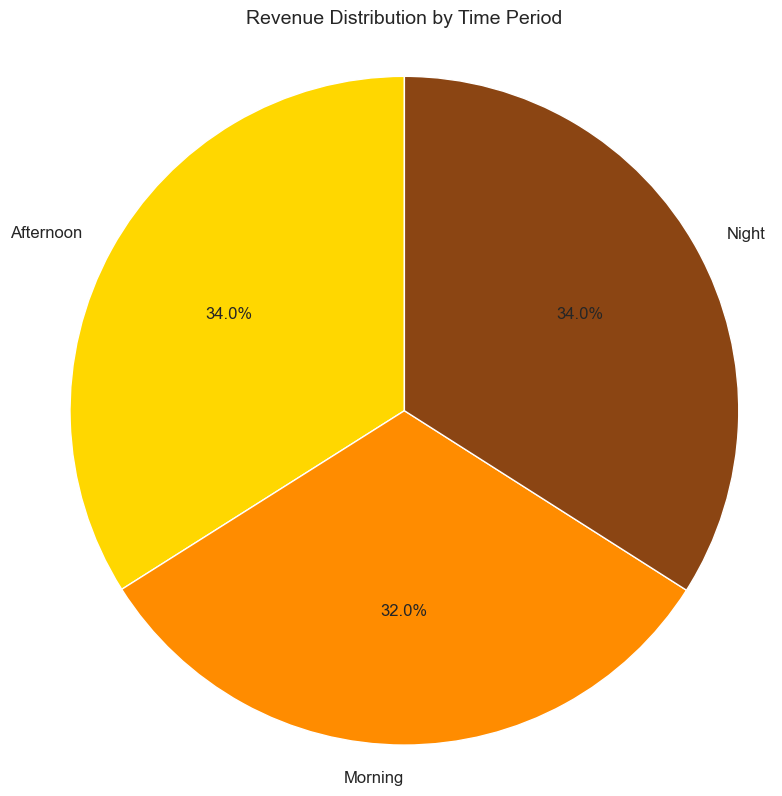


--- Key Insights for Time Period Sales ---
1. Highest revenue period: Night (Accounting for 34.0% of total revenue)
2. Lowest revenue period: Morning (Accounting for 32.0% of total revenue)


In [12]:
time_period_sales = df.groupby("Time_of_Day", observed = True)["money"].sum()

plt.figure(figsize = (8, 8))
plt.pie(time_period_sales, 
        labels = time_period_sales.index, 
        autopct = '%1.1f%%', 
        startangle = 90, 
        colors = ['#FFD700', '#FF8C00', '#8B4513'],
        textprops = {'fontsize': 12})
plt.title("Revenue Distribution by Time Period", fontsize = 14, pad = 20)
plt.axis('equal')
plt.tight_layout()
plt.show()

print("\n--- Key Insights for Time Period Sales ---")
print(f"1. Highest revenue period: {time_period_sales.idxmax()} (Accounting for {time_period_sales.max()/time_period_sales.sum()*100:.1f}% of total revenue)")
print(f"2. Lowest revenue period: {time_period_sales.idxmin()} (Accounting for {time_period_sales.min()/time_period_sales.sum()*100:.1f}% of total revenue)")

In [2]:
print("""=== FINAL CONCLUSION & STRATEGIC INSIGHTS ===

1. Core Business Pattern
This dataset shows a balanced sales structure across morning, afternoon, and night, which is different from traditional coffee shops that rely only on morning peaks. The business runs steadily throughout the day with stable customer demand.

2. Product & Revenue Structure
The shop’s revenue mainly comes from a few best-selling products, especially Latte. This structure is efficient but also brings risks because over-reliance on limited products may affect business stability. Developing new products or limited specials can help improve sustainability.

3. Time Demand & Operational Efficiency
Sales are distributed evenly all day rather than concentrated in the morning. Although 10 AM has the highest transaction volume, the shop maintains strong performance in the afternoon and night. This means stable staffing and inventory are required for the whole business day.

4. Customer Behavior & Payment Trends
All customers use card payments, showing that the customer group is modern and prefers digital payment methods. Stable payment systems are essential for smooth operation.

5. Seasonality & Long-Term Planning
Sales are higher on weekdays and lower on Sundays, with peak season in March and off-season in April. The main customers are likely office workers, so targeted promotions can help improve sales in low periods.

6. Strategic Value
This analysis turns raw data into practical business suggestions, helping the shop optimize operations, reduce costs, increase profits, and build a more sustainable and professional operation.""")

=== FINAL CONCLUSION & STRATEGIC INSIGHTS ===

1. Core Business Pattern
This dataset shows a balanced sales structure across morning, afternoon, and night, which is different from traditional coffee shops that rely only on morning peaks. The business runs steadily throughout the day with stable customer demand.

2. Product & Revenue Structure
The shop’s revenue mainly comes from a few best-selling products, especially Latte. This structure is efficient but also brings risks because over-reliance on limited products may affect business stability. Developing new products or limited specials can help improve sustainability.

3. Time Demand & Operational Efficiency
Sales are distributed evenly all day rather than concentrated in the morning. Although 10 AM has the highest transaction volume, the shop maintains strong performance in the afternoon and night. This means stable staffing and inventory are required for the whole business day.

4. Customer Behavior & Payment Trends
All customers 